# CCCOH: GENIE covariance matrices

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
syst_name = ("GENIE",)
output_str = "genie"

In [3]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime

import uproot

import sys
sys.path.append('../../../')
from pyanalib.split_df_helpers import *
import pyanalib.pandas_helpers as ph
from analysis_village.unfolding.covariance import *
from analysis_village.unfolding.utils import *

from cohpi_topologies import *
from var_config_cohpi import *

np.seterr(divide='ignore', invalid='ignore', over='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## 1. Open MC df

### 1 - 1: File path and name

In [4]:
input_path = "/data/sungbino/sbnd/v10_14_02/cohpi/"

## -- this file is based on 
####    geniewgtdf = geniesyst.geniesyst(f, nudf.ind, multisim_nuniv=100, slim=True, systematics=None)
####    bnbwgtdf = bnbsyst.bnbsyst(f, nudf.ind, multisim_nuniv=100, slim=True)
mc_file_name = "mc_MCP2025C_FallValidationII_prodgenie_corsika_proton_rockbox0p1_sbnd_CV_caf_flat_caf_sbnd_cohpi_wienersvd_slim_genie_clip_wgt.df"

mc_file_path = path.join(input_path, mc_file_name)

### 1 - 2: Check df keys and n_split

In [5]:
print("n split", get_n_split(mc_file_path))
print("Keys in mc file:")
print_keys(mc_file_path)

n split 2
Keys in mc file:
Keys: ['/evt_0', '/evt_1', '/hdr_0', '/hdr_1', '/histgenevtdf_0', '/histgenevtdf_1', '/histpotdf_0', '/histpotdf_1', '/mcnu_0', '/mcnu_1', '/pot_0', '/pot_1', '/split']


### 1 - 3: Load the dfs

Note:
- mc_evt_df is skimmed df with a single level for columns.
- mc_mcnu_df is skimmed df but with two levels for columns. second level is for multiverse weights

In [6]:
mc_keys2load = ['hdr', "mcnu", 'evt']
mc_dfs = load_dfs(mc_file_path, mc_keys2load, n_max_concat=10)
mc_evt_df = mc_dfs['evt']
mc_hdr_df = mc_dfs['hdr']
mc_mcnu_df = mc_dfs['mcnu']

In [7]:
mc_evt_df.columns

Index(['is_fv', 'is_not_clear_cosmic', 'n_prong', 'n_trk', 'n_proton',
       'n_shower', 'tmatch_idx', 'tmatch_eff', 'tmatch_purity', 'long_dirx',
       'long_diry', 'long_dirz', 'short_dirx', 'short_diry', 'short_dirz',
       'long_dirz_pass', 'short_dirz_pass', 'vtx_x', 'vtx_y', 'vtx_z',
       'long_trk_len', 'short_trk_len', 'long_trk_pid', 'short_trk_pid',
       'reco_t', 'opening_angle', 'is_muon_contained', 'is_cpi_contained',
       'range_p_mu', 'range_p_cpi', 'total_pe', 'sum_integ_4cm',
       'sum_integ_3cm', 'sum_integ_2cm', 'sum_integ_1cm',
       'sum_integ_ratio_3over4sub'],
      dtype='object')

In [8]:
mc_mcnu_df.columns[0:10]

MultiIndex([(       'genie_mode',       ''),
            (        'true_E_nu',       ''),
            (        'true_p_mu',       ''),
            (        'true_p_pi',       ''),
            ('true_cos_theta_mu',       ''),
            ('true_cos_theta_pi',       ''),
            (           'true_t',       ''),
            (      'nuint_categ',       ''),
            (            'GENIE', 'univ_0'),
            (            'GENIE', 'univ_1')],
           )

## 2. Normalization Variables

POT

In [9]:
mc_tot_pot = mc_hdr_df['pot'].sum()
print("Total MC POT:", mc_tot_pot)
mc_pot_scale = 1.
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

tot_pot = mc_tot_pot

Total MC POT: 7.208405e+19


Volume

In [10]:
TPC_Vol = (180. * 2.) * (190. * 2) * (250. - 10.) + (180. * 2.) * (190. + 100.) * (450. - 250.) # cm^3

Flux

In [11]:
fluxfile = "/data/sungbino/sbnd/flux/sbnd_original_flux.root"
flux = uproot.open(fluxfile)
numu_flux = flux["flux_sbnd_numu"].to_numpy()
anumu_flux = flux["flux_sbnd_anumu"].to_numpy()
numu_flux_vals = numu_flux[0]
anumu_flux_vals = anumu_flux[0]

INTEGRATED_FLUX = (numu_flux_vals.sum() + anumu_flux_vals.sum()) / (1e4  * 1e6) # to cm2 # to POT
print("Integrated flux (numu + anumu) over total MC POT: %.3e per (cm^2 POT)" % INTEGRATED_FLUX)

Integrated flux (numu + anumu) over total MC POT: 1.735e-08 per (cm^2 POT)


## 3. match mc_evt_df and mc_mcnu_df

In [12]:
mc_evt_df = ph.multicol_merge(mc_evt_df.reset_index(), mc_mcnu_df.reset_index(),
                               left_on=[("__ntuple", ""), ("entry", ""), ("tmatch_idx", "")],
                               right_on=[("__ntuple", ""), ("entry", ""), ("rec.mc.nu..index", "")],
                               how="left") ## -- save all sllices
mc_evt_df.loc[mc_evt_df['nuint_categ'].isna(), ['nuint_categ']] = -2

In [13]:
mc_evt_df.nuint_categ.value_counts()

nuint_categ
 5.0    400
 1.0    192
 6.0    114
 0.0     72
 4.0     42
 3.0     31
-2.0     27
-1.0      4
Name: count, dtype: int64

## 4. Spiltting to signal region (SR) and sideband (SB)

- Signal region: reco |t| < 0.04 (GeV/c)^2
- Sideband: 0.06 (GeV/c)^2 < reco |t| < 0.16 (GeV/c)^2

In [14]:
mc_evt_df_sr = mc_evt_df[mc_evt_df.reco_t < 0.04]
mc_evt_df_sb = mc_evt_df[(mc_evt_df.reco_t > 0.06) & (mc_evt_df.reco_t < 0.16)]

## 5. Cross Section Variable Configs

P_mu

In [15]:
mc_evt_df

__ntuple entry rec.slc..index is_fv is_not_clear_cosmic n_prong n_trk  \
                                                                            
0          3   880              0  True                True       2     2   
1          8   358              0  True                True       2     2   
2          1   393              1  True                True       2     2   
3          4   701              0  True                True       2     2   
4         17   628              0  True                True       2     2   
..       ...   ...            ...   ...                 ...     ...   ...   
877      997  1136              0  True                True       2     2   
878      999   828              0  True                True       2     2   
879      993   116              2  True                True       2     2   
880      993   684              0  True                True       2     2   
881      976  1098              0  True                True       2     2   

    n_proton n_shower tmatch_idx  ...     GENIE                       \
                                  ...   univ_90    univ_91   univ_92   
0          0        0          1  ...  2.864210  11.537339  3.106292   
1          0        0          2  ...  1.690994   3.838002  1.571798   
2          0        0          0  ...  0.501258   0.643914  1.539333   
3          0        0          0  ...  0.742597   0.424539  0.660609   
4          0        0          0  ...  0.552708   1.562130  0.467909   
..       ...      ...        ...  ...       ...        ...       ...   
877        0        0          1  ...  0.851038   0.385549  1.421977   
878        0        0          0  ...  0.257192   0.236403  1.275530   
879        0        0          0  ...  0.818512   2.706587  0.191099   
880        0        0          1  ...  0.825982   0.747880  1.502647   
881        0        0          0  ...  0.396817   0.373667  1.768782   

                                                                           
      univ_93   univ_94   univ_95   univ_96   univ_97   univ_98   univ_99  
0    1.487508  1.419669  2.041423  5.409585  5.401626  0.461163  0.595474  
1    2.728052  0.166048  2.430815  3.259298  0.814127  0.000000  2.924360  
2    0.882783  1.108859  1.239452  0.885842  1.020563  0.676534  0.214801  
3    1.104822  2.512453  3.230256  0.123944  0.634136  2.163885  1.178936  
4    0.864212  0.395491  0.135444  1.690737  0.973429  0.299131  0.335364  
..        ...       ...       ...       ...       ...       ...       ...  
877  1.925842  0.649696  1.767407  0.829544  1.149947  0.918332  1.183158  
878  0.641996  0.464809  0.758400  0.505573  0.742003  0.593322  0.623631  
879  0.000000  1.620201  0.789993  1.195686  1.278034  1.203538  0.552116  
880  1.480279  0.990828  2.010481  0.708831  0.871381  0.847004  1.230371  
881  0.853183  0.658243  1.449636  0.623193  0.815559  0.475598  0.248511  

[882 rows x 149 columns]

## 5. Signal histograms

"All Signal in MC" are the same in SR and SB

No pot_weight column found, return 1 as pot scale (expected for data)


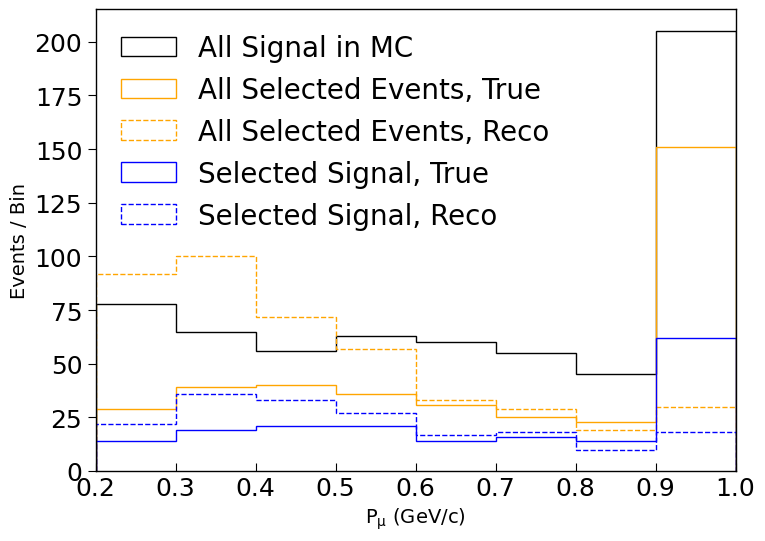

No pot_weight column found, return 1 as pot scale (expected for data)


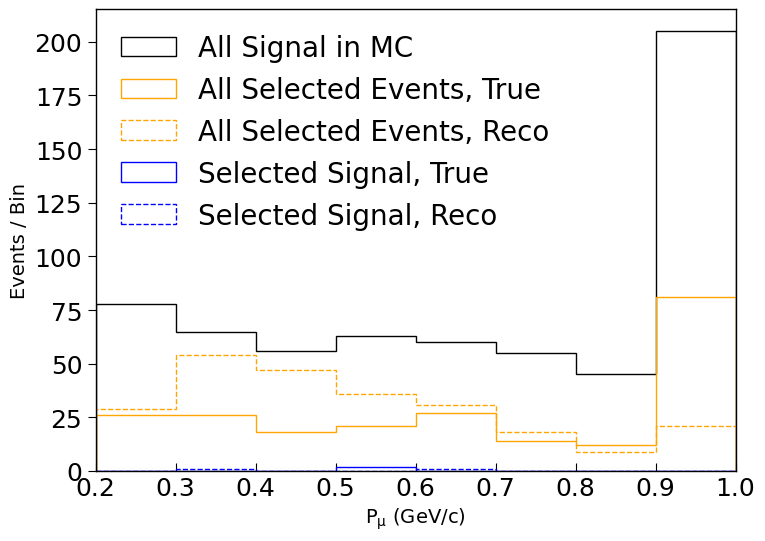

In [30]:
sighist_res = signal_hists(evtdf=mc_evt_df_sr, nudf=mc_mcnu_df, var_config=varcfg_p_mu, save_fig=False, save_name=None, return_data=True)
signal_hists(evtdf=mc_evt_df_sb, nudf=mc_mcnu_df, var_config=varcfg_p_mu, save_fig=False, save_name=None)

### 5 - 1: Response Matrix

In [39]:
sighist_res["nevts_allmc"]

array([ 78.,  65.,  56.,  63.,  60.,  55.,  45., 205.])

[[ 7.  3.  4.  0.  0.  0.  0.  0.]
 [ 4. 14.  1.  0.  0.  0.  0.  0.]
 [ 1.  5. 13.  2.  0.  0.  0.  0.]
 [ 1.  2.  4. 13.  1.  0.  0.  0.]
 [ 2.  2.  1.  1.  7.  1.  0.  0.]
 [ 0.  2.  5.  1.  2.  6.  0.  0.]
 [ 1.  0.  3.  1.  2.  3.  4.  0.]
 [ 6.  8.  2.  9.  5.  8.  6. 18.]]


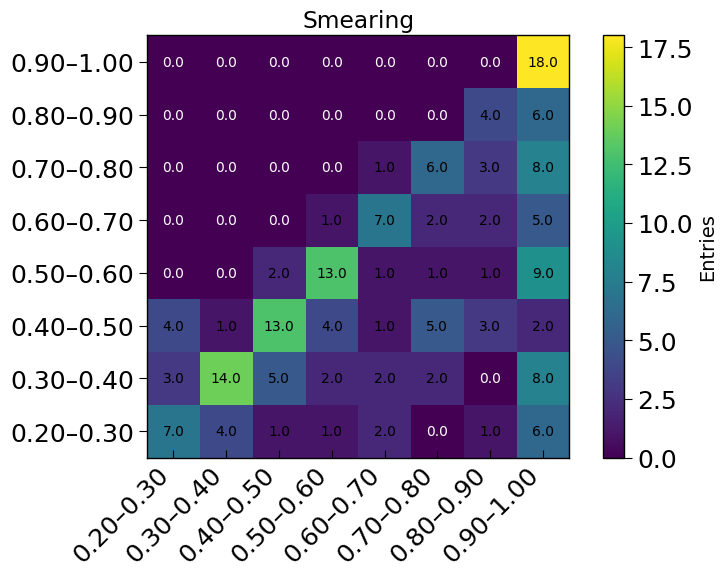

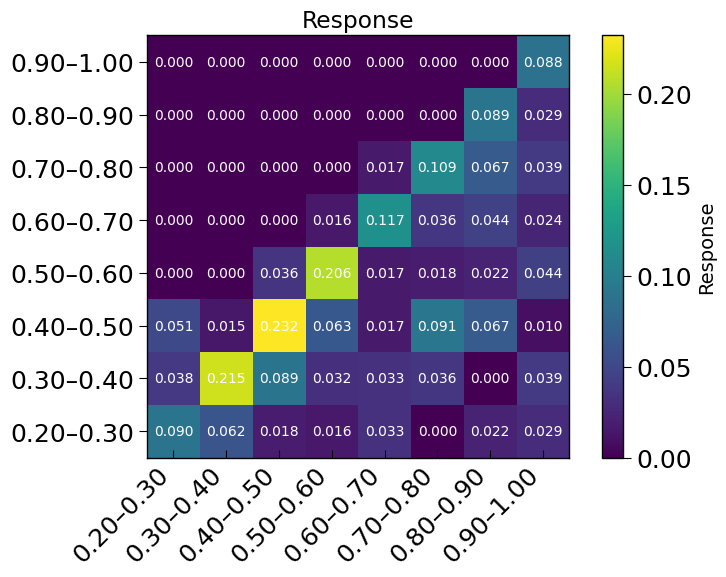

In [37]:
reco_vs_true = get_smear_matrix(sighist_res["var_sel_truth"], sighist_res["var_sel_reco"], bins_2d=[varcfg_p_mu.bins, varcfg_p_mu.bins], plot=True)
eff = get_eff(reco_vs_true, sighist_res["nevts_allmc"])
response = get_response_matrix(reco_vs_true, eff, varcfg_p_mu.bins, plot=True)


## 6. Collect Histograms in CV and Multiverses

### 6 - 1: collect events in CV + multiverses, in each region

In [17]:
cov_type = "xsec"
sr_signal_univ_events, sr_signal_sel_reco_cv, sr_bkg_univ_events, sr_bkg_sec_rec_cv = get_genie_univs(cov_type, mc_evt_df_sr, mc_mcnu_df, varcfg_p_mu, syst_name, flux=INTEGRATED_FLUX, pot=tot_pot, vol=TPC_Vol, topology_list=mode_list)
sb_signal_univ_events, sb_signal_sel_reco_cv, sb_bkg_univ_events, sb_bkg_sec_rec_cv = get_genie_univs(cov_type, mc_evt_df_sb, mc_mcnu_df, varcfg_p_mu, syst_name, flux=INTEGRATED_FLUX, pot=tot_pot, vol=TPC_Vol, topology_list=mode_list)

getting 100 universes for ('GENIE',) uncertainty on the xsec
XSEC_UNIT: {7.132e-43}
NTARGETS: {1.121e+30}
No pot_weight column found, return 1 as pot scale (expected for data)
getting 100 universes for ('GENIE',) uncertainty on the xsec
XSEC_UNIT: {7.132e-43}
NTARGETS: {1.121e+30}
No pot_weight column found, return 1 as pot scale (expected for data)


### 6 - 2: plot CV vs. Multiverse plots in SR

#### 6 - 2 - a: Signal

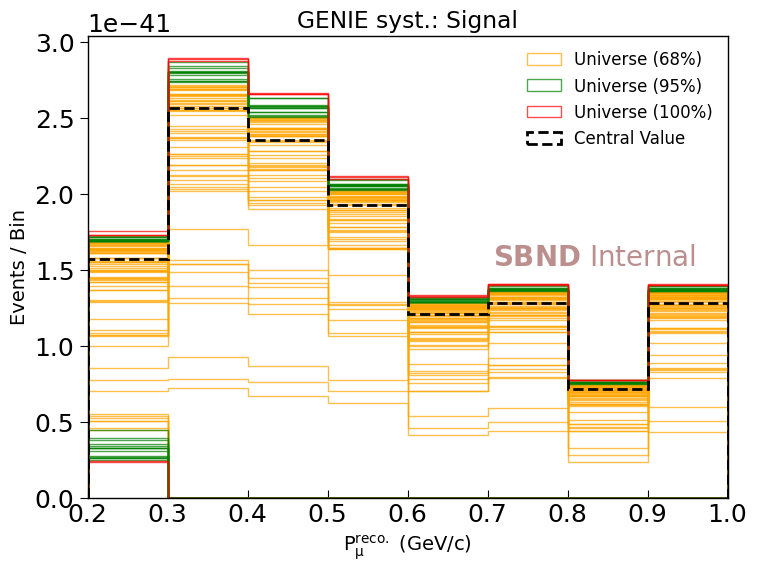

In [18]:
plot_univ_hists(sr_signal_univ_events, sr_signal_sel_reco_cv, "GENIE", varcfg_p_mu, categ_name="Signal")

#### 6 - 2 - b: backgrounds

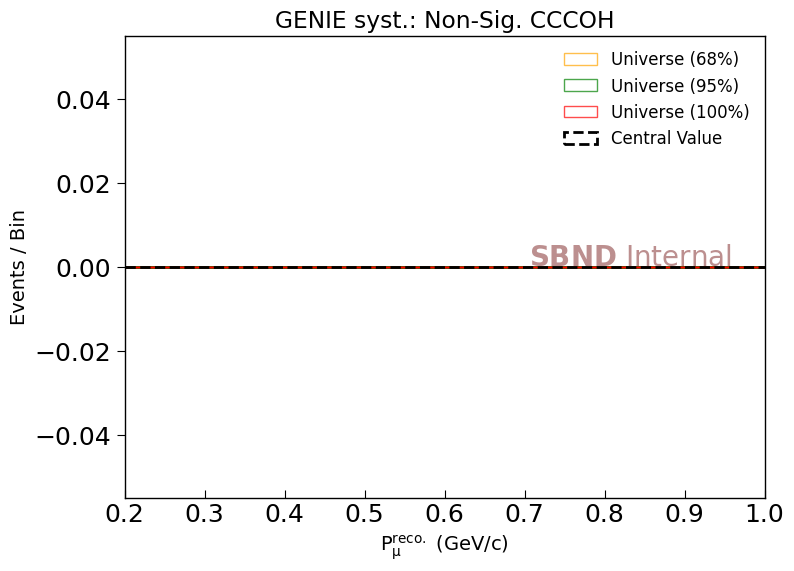

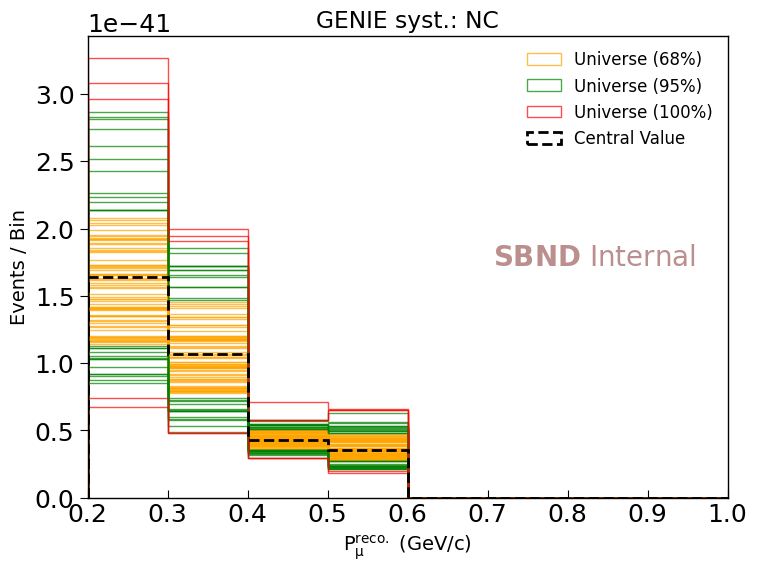

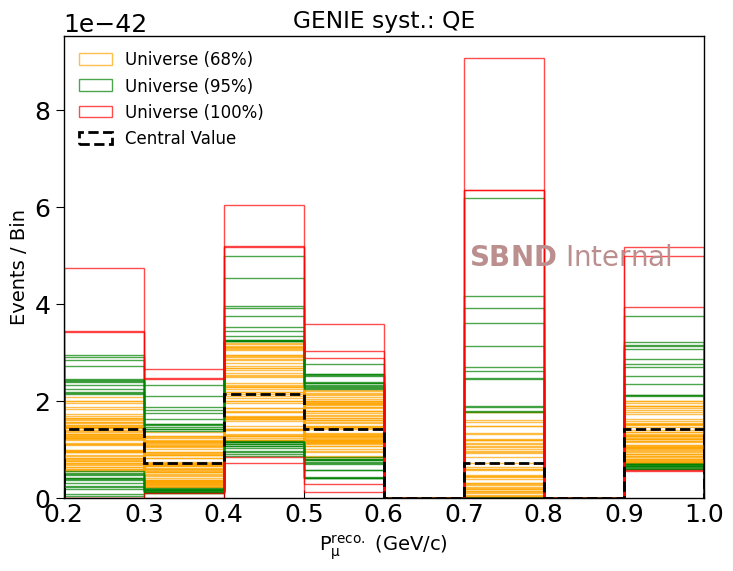

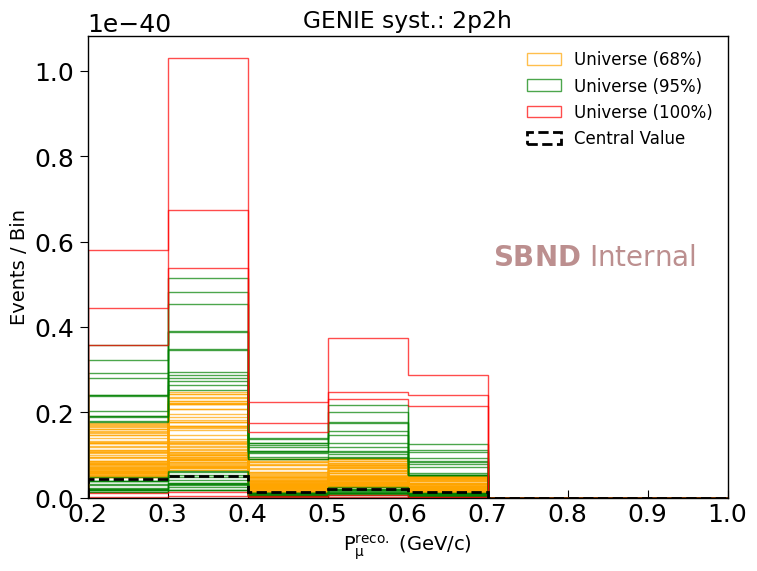

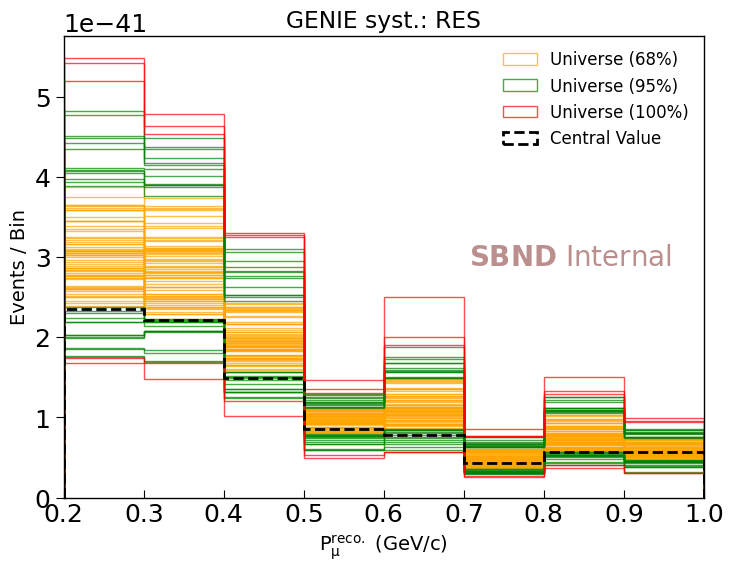

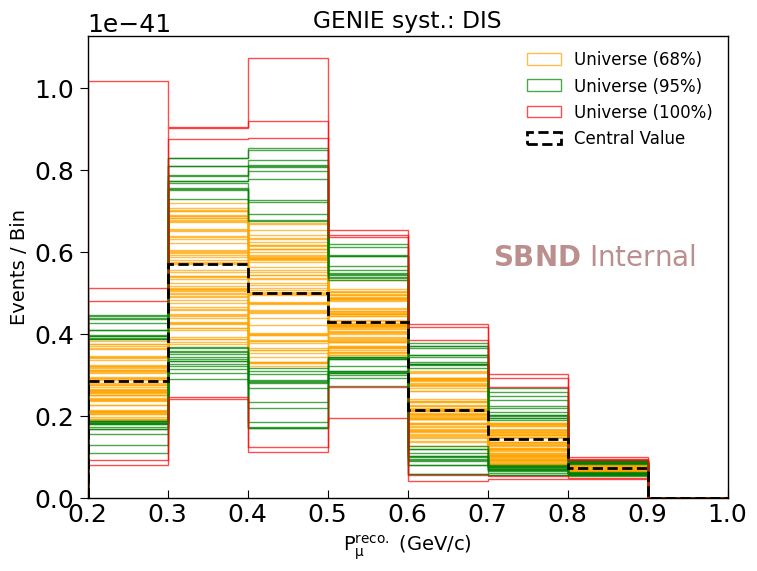

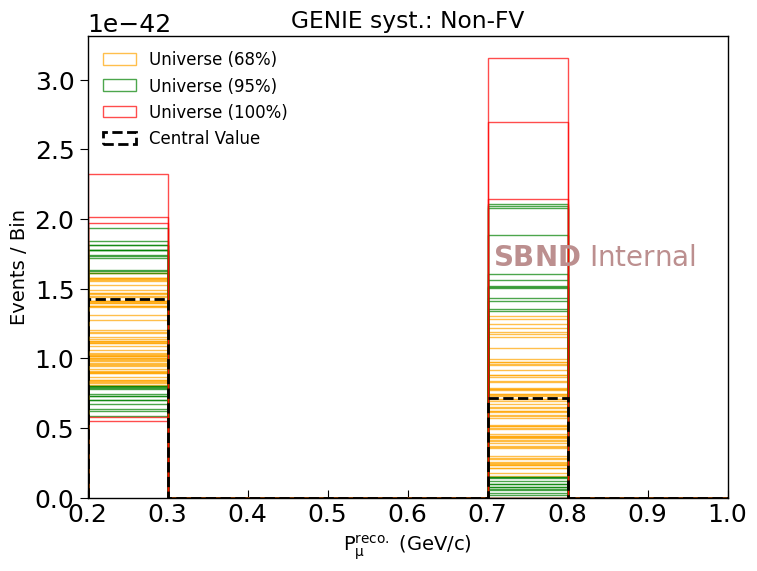

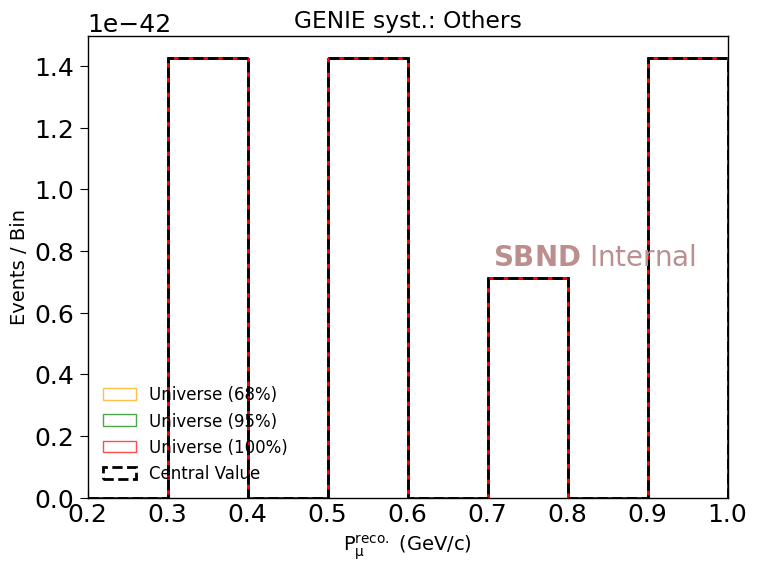

In [19]:
for i in range(len(mode_list))[1:]:
    this_mode_name = mode_labels[i]
    this_categ_univ_events = sr_bkg_univ_events[:, i - 1, :]
    plot_univ_hists(this_categ_univ_events, sr_bkg_sec_rec_cv[i - 1], "GENIE", varcfg_p_mu, categ_name=this_mode_name)

### 6 - 2: plot CV vs. Multiverse plots in SB

#### 6 - 2 - a: Signal

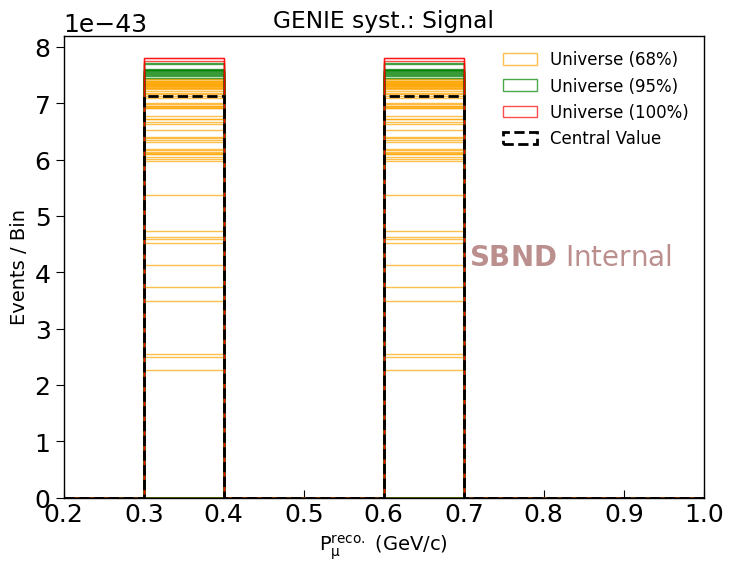

In [20]:
plot_univ_hists(sb_signal_univ_events, sb_signal_sel_reco_cv, "GENIE", varcfg_p_mu, categ_name="Signal")

#### 6 - 2 - b: Background

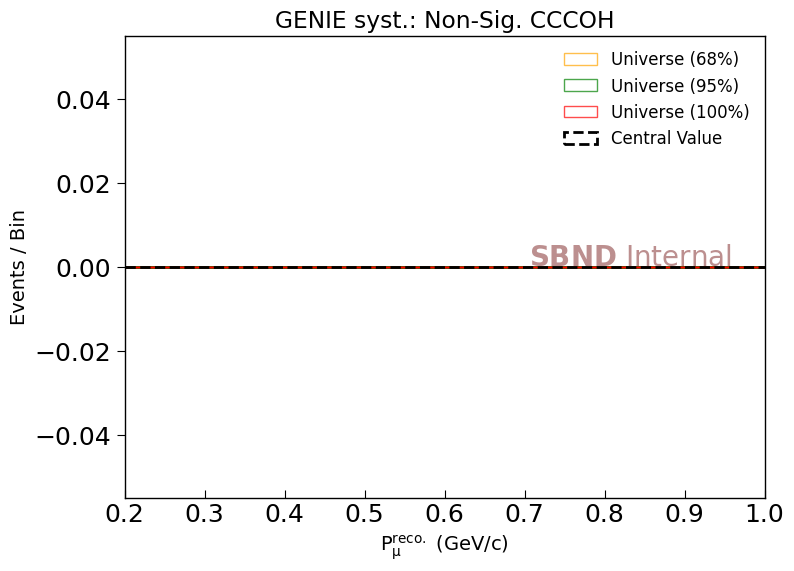

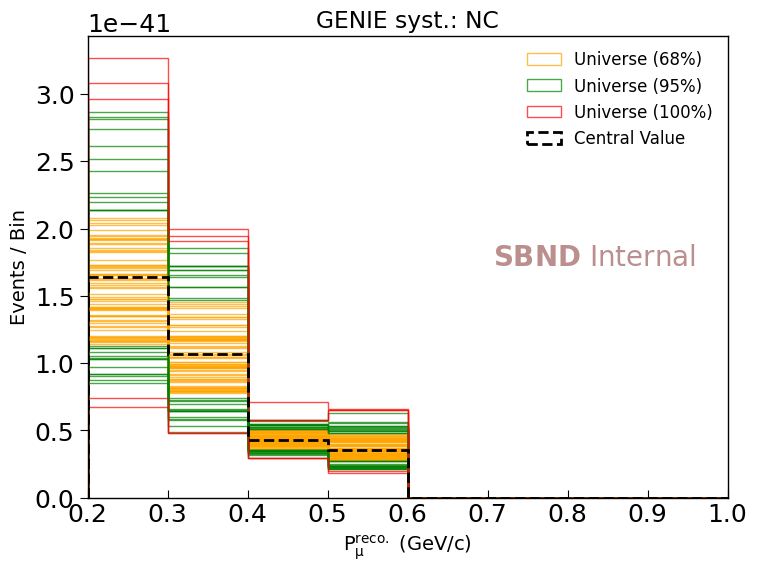

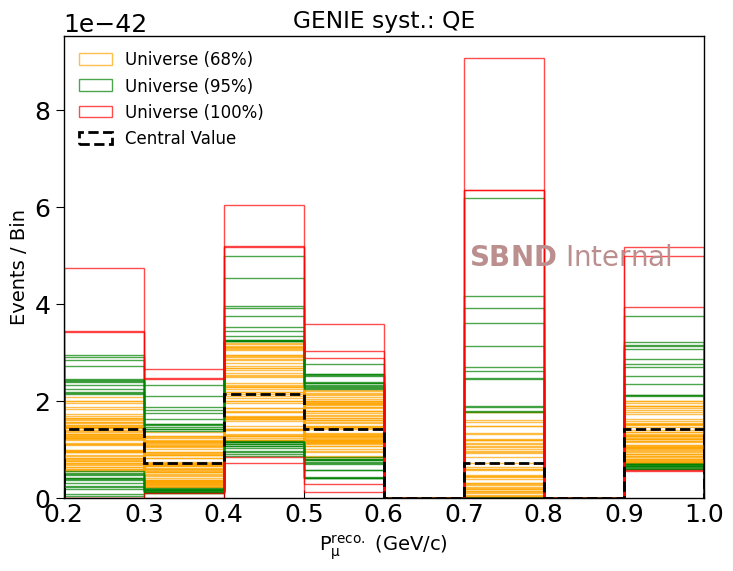

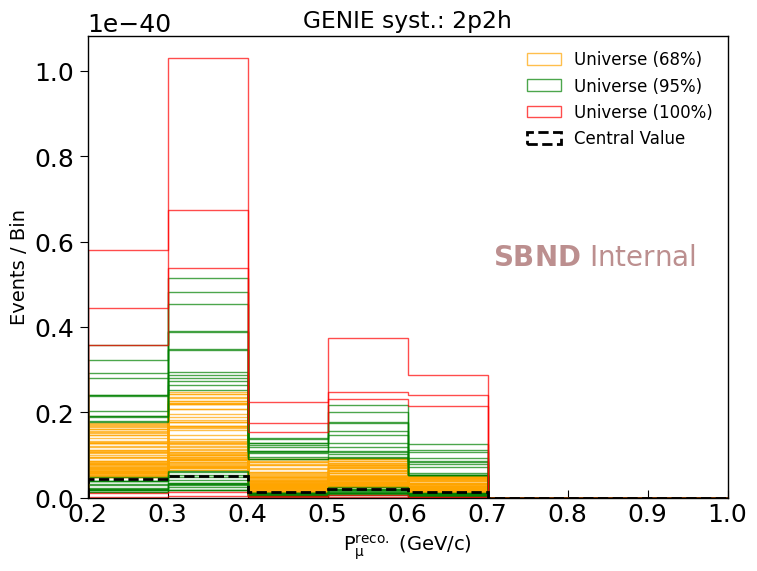

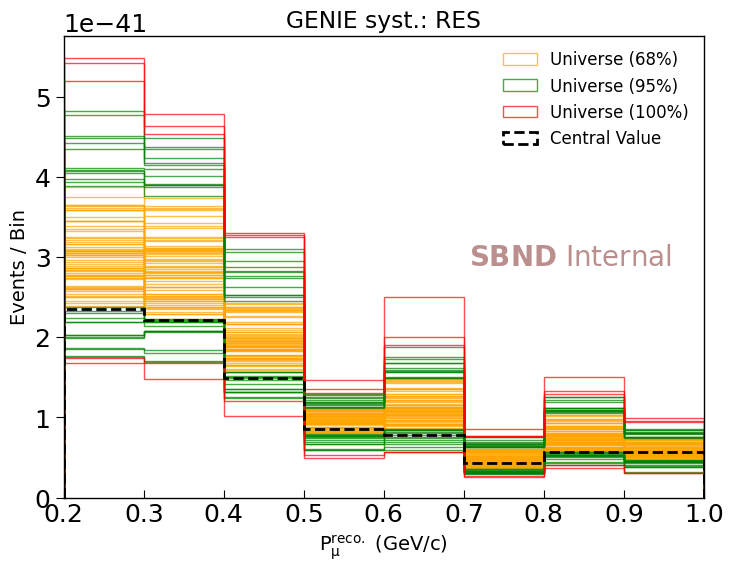

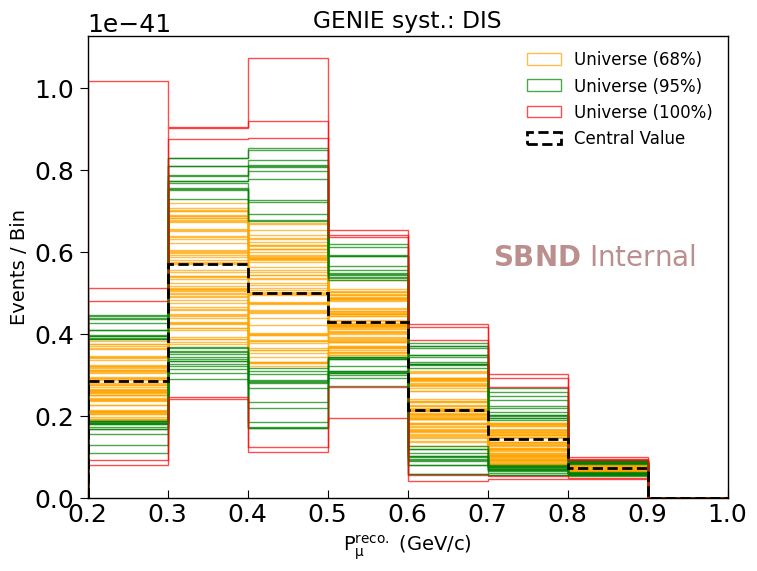

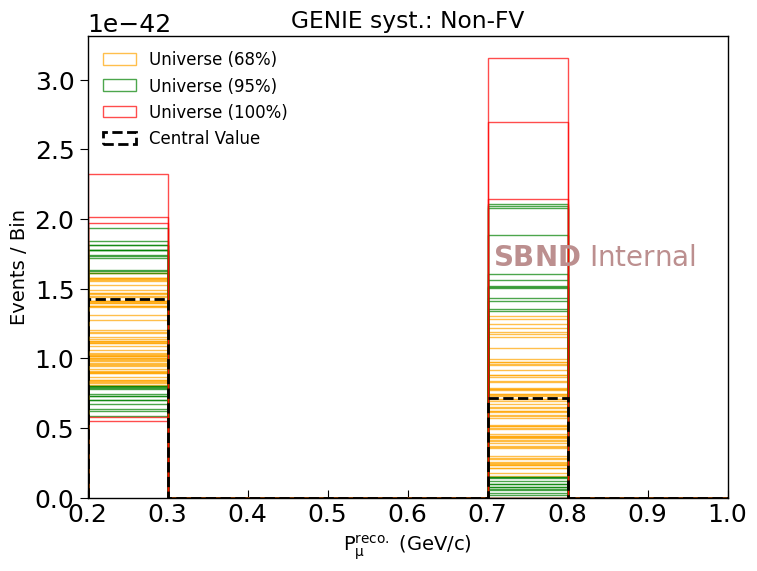

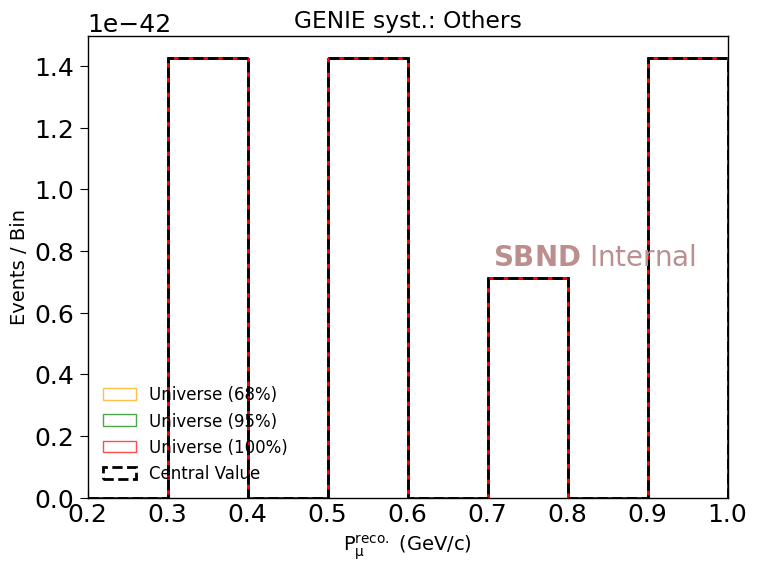

In [21]:
for i in range(len(mode_list))[1:]:
    this_mode_name = mode_labels[i]
    this_categ_univ_events = sr_bkg_univ_events[:, i - 1, :]
    plot_univ_hists(this_categ_univ_events, sr_bkg_sec_rec_cv[i - 1], "GENIE", varcfg_p_mu, categ_name=this_mode_name)

## 7. Covariance Matrices

For CCBC, we consider signal events (m) and background events (b) in signal region (s) and sideband (c)

We need these self-covariance matrices
1. Cov(m_s, m_s): cov_ms_ms
2. Cov(b_s, b_s): cov_bs_bs
3. Cov(m_c, m_c): cov_mc_mc
4. Cov(b_c, b_c): cov_bc_bc

In addition, we also need

5. Cov(m_s, b_s), Cov(b_s, m_s): cov_ms_bs, cov_bs_ms
6. Cov(m_s, m_c), Cov(m_c, m_s): cov_ms_mc, cov_mc_ms
7. Cov(m_s, b_c), Cov(b_c, m_s): cov_ms_bc, cov_bc_ms
8. Cov(b_s, m_c), Cov(m_c, b_s): cov_bs_mc, cov_mc_bs
9. Cov(b_s, b_c), Cov(b_c, b_s): cov_bs_bc, cov_bc_bs
10. Cov(m_c, b_c), Cov(b_c, m_c): cov_mc_bc, cov_bc_mc

### 7 - 1: Signal region, cov_ms_ms and cov_bs_bs

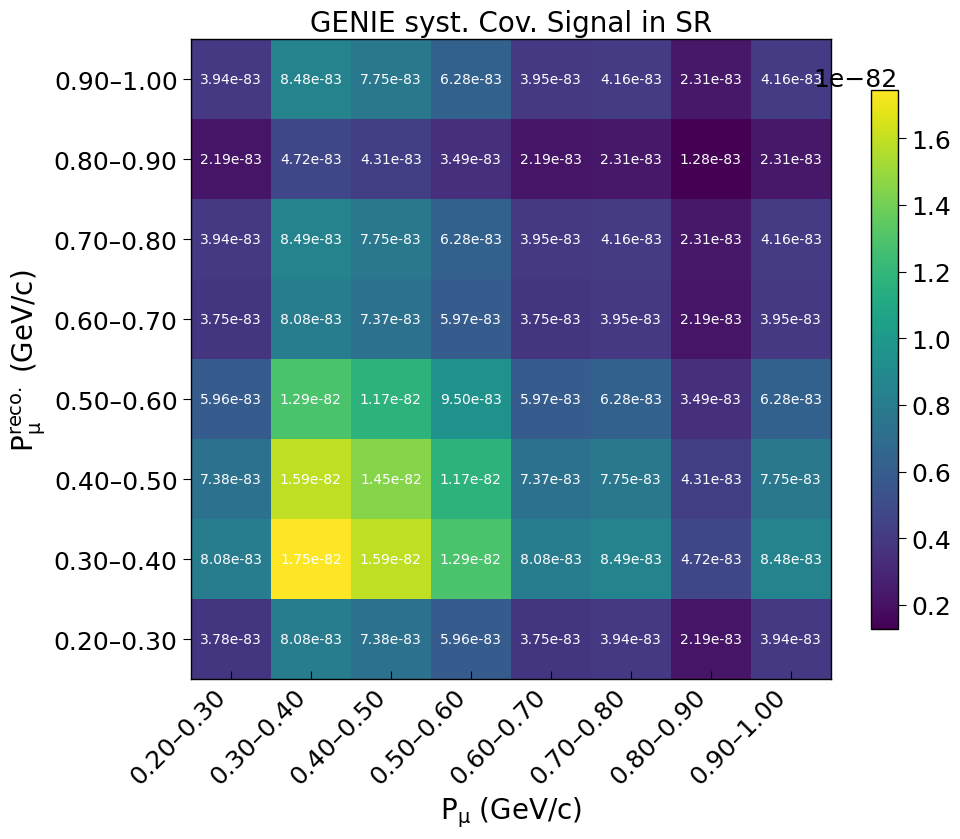

In [22]:
cov_ms_ms = get_covariance_matrix_self(sr_signal_univ_events, sr_signal_sel_reco_cv)
plot_heatmap(cov_ms_ms["cov"], varcfg_p_mu, title="GENIE syst. Cov. Signal in SR")

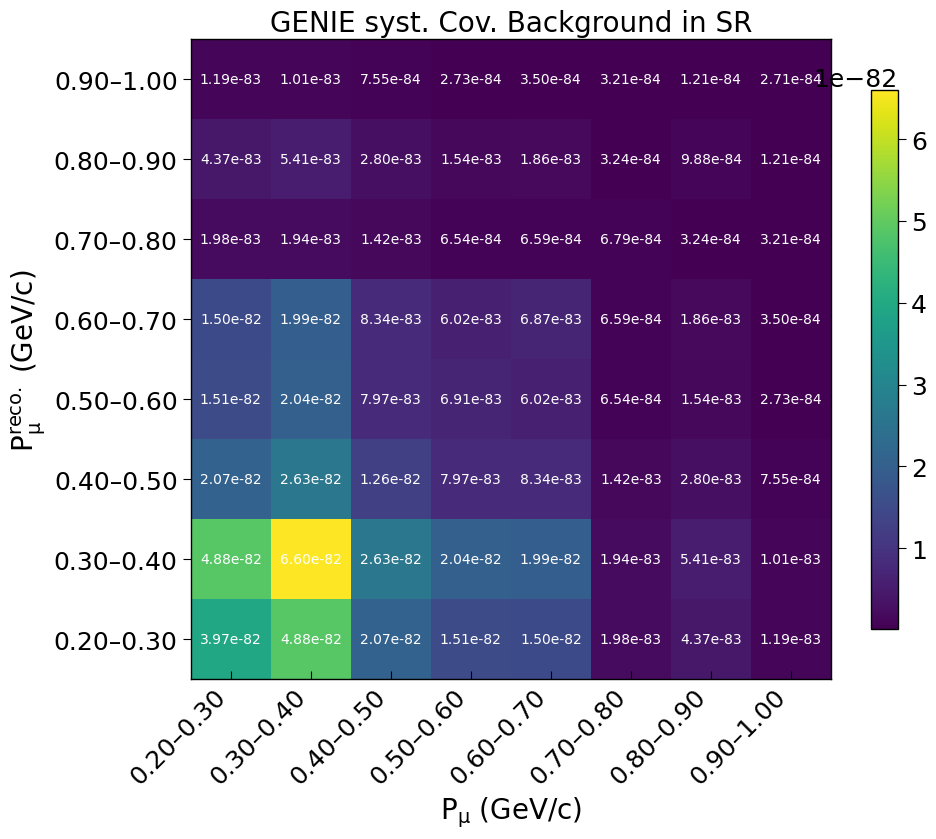

In [23]:
### For the total background
sr_total_bkg_sec_rec_cv = sr_bkg_sec_rec_cv.sum(axis=0)
sr_total_bkg_univ_events = sr_bkg_univ_events.sum(axis=1)
cov_bs_bs = get_covariance_matrix_self(sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv)
plot_heatmap(cov_bs_bs["cov"], varcfg_p_mu, title="GENIE syst. Cov. Background in SR")

### 7 - 2: Sideband, cov_mc_mc and cov_bc_bc

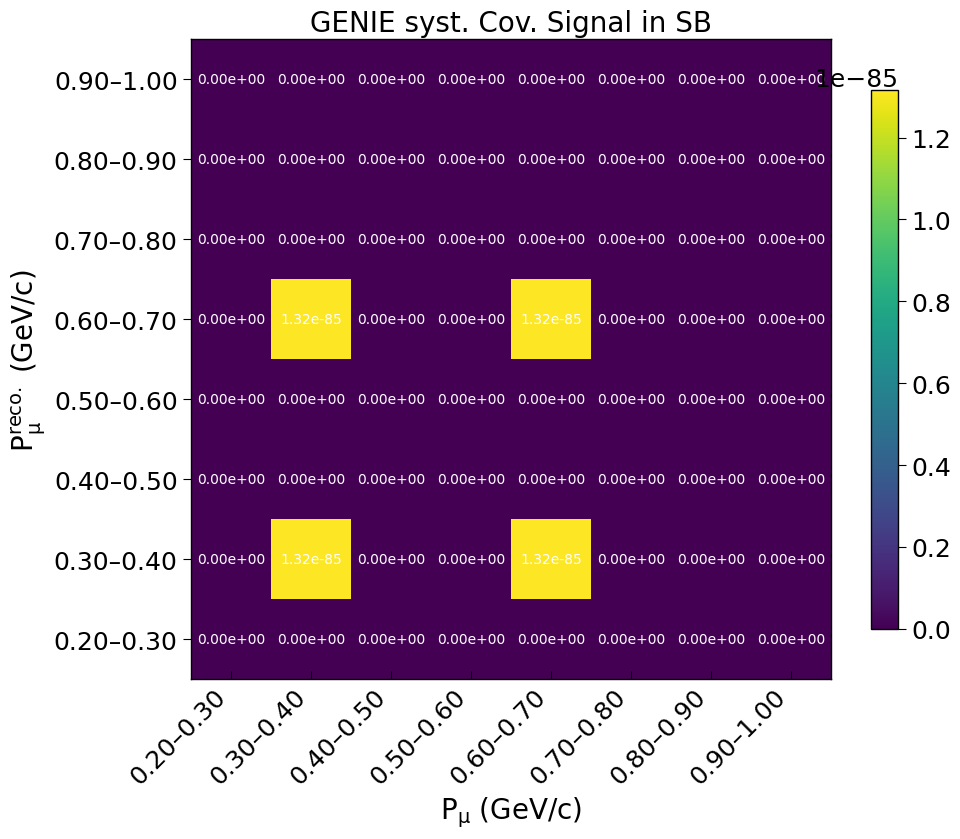

In [24]:
cov_mc_mc = get_covariance_matrix_self(sb_signal_univ_events, sb_signal_sel_reco_cv)
plot_heatmap(cov_mc_mc["cov"], varcfg_p_mu, title="GENIE syst. Cov. Signal in SB")

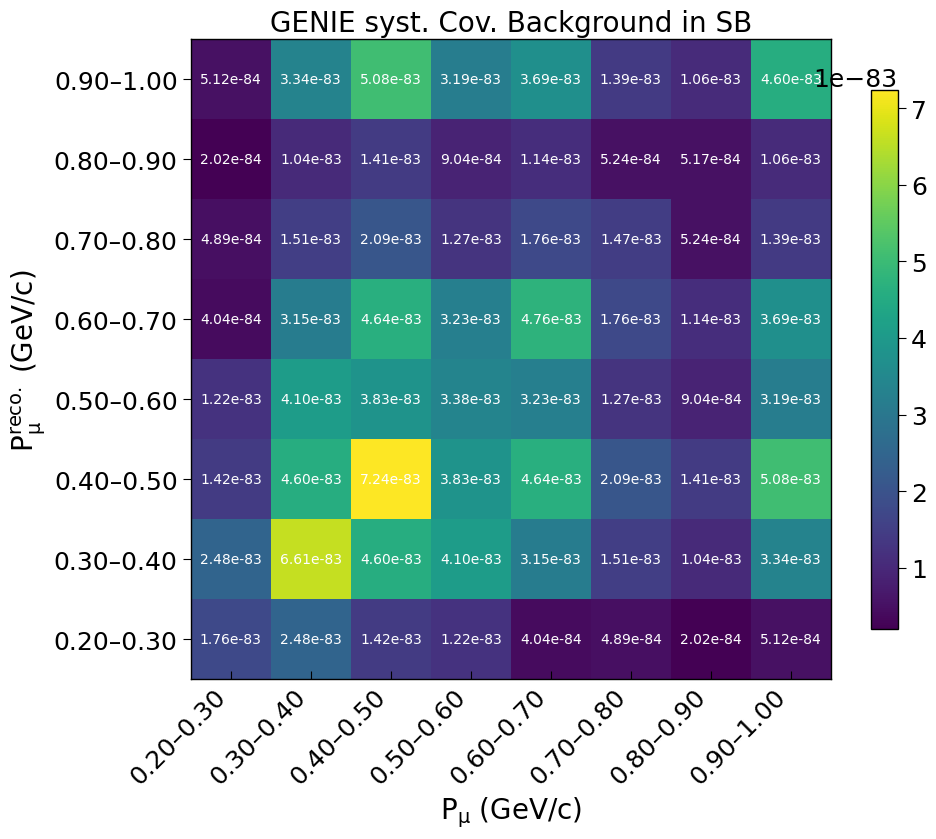

In [25]:
### For the total background
sb_total_bkg_sec_rec_cv = sb_bkg_sec_rec_cv.sum(axis=0)
sb_total_bkg_univ_events = sb_bkg_univ_events.sum(axis=1)
cov_bc_bc = get_covariance_matrix_self(sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv)
plot_heatmap(cov_bc_bc["cov"], varcfg_p_mu, title="GENIE syst. Cov. Background in SB")

### 7 - 3: Crossing covariance matrices

In [26]:
cov_ms_bs = get_covariance_matrix(sr_signal_univ_events, sr_signal_sel_reco_cv, sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv)
cov_bs_ms = get_covariance_matrix(sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv, sr_signal_univ_events, sr_signal_sel_reco_cv)

cov_ms_mc = get_covariance_matrix(sr_signal_univ_events, sr_signal_sel_reco_cv, sb_signal_univ_events, sb_signal_sel_reco_cv)
cov_mc_ms = get_covariance_matrix(sb_signal_univ_events, sb_signal_sel_reco_cv, sr_signal_univ_events, sr_signal_sel_reco_cv)

cov_ms_bc = get_covariance_matrix(sr_signal_univ_events, sr_signal_sel_reco_cv, sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv)
cov_bc_ms = get_covariance_matrix(sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv, sr_signal_univ_events, sr_signal_sel_reco_cv)

cov_bs_mc = get_covariance_matrix(sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv, sb_signal_univ_events, sb_signal_sel_reco_cv)
cov_mc_bs = get_covariance_matrix(sb_signal_univ_events, sb_signal_sel_reco_cv, sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv)

cov_bs_bc = get_covariance_matrix(sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv, sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv)
cov_bc_bs = get_covariance_matrix(sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv, sr_total_bkg_univ_events, sr_total_bkg_sec_rec_cv)

cov_mc_bc = get_covariance_matrix(sb_signal_univ_events, sb_signal_sel_reco_cv, sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv)
cov_bc_mc = get_covariance_matrix(sb_total_bkg_univ_events, sb_total_bkg_sec_rec_cv, sb_signal_univ_events, sb_signal_sel_reco_cv)

## 8. Save CV hists and Cov matrices

In [40]:
ret_dict = {
    "ms": sr_signal_sel_reco_cv,
    "bs": sr_total_bkg_sec_rec_cv,
    "mc": sb_signal_sel_reco_cv,
    "bc": sb_total_bkg_sec_rec_cv,
    "cov_ms_ms": cov_ms_ms,
    "cov_bs_bs": cov_bs_bs,
    "cov_mc_mc": cov_mc_mc,
    "cov_bc_bc": cov_bc_bc,
    "cov_ms_bs": cov_ms_bs,
    "cov_bs_ms": cov_bs_ms,
    "cov_ms_mc": cov_ms_mc,
    "cov_mc_ms": cov_mc_ms,
    "cov_ms_bc": cov_ms_bc,
    "cov_bc_ms": cov_bc_ms,
    "cov_bs_mc": cov_bs_mc,
    "cov_mc_bs": cov_mc_bs,
    "cov_bs_bc": cov_bs_bc,
    "cov_bc_bs": cov_bc_bs,
    "cov_mc_bc": cov_mc_bc,
    "cov_bc_mc": cov_bc_mc,
    "response": response,
    "true_signal": sighist_res["nevts_allmc"],
}

np.savez(output_str + "_syst_cov_matrices.npz", **ret_dict)